In [25]:
from pathlib import Path

import pandas as pd

fichiers = sorted(Path("../data/raw").glob("dvf_34172_*.csv"))
df = pd.concat([pd.read_csv(f, low_memory=False) for f in fichiers], ignore_index=True)
df["date_mutation"] = pd.to_datetime(df["date_mutation"])
df["annee"] = df["date_mutation"].dt.year
print(df.shape)
df.head()

(81361, 41)


,id_mutation,date_mutation,numero_disposition,nature_mutation,valeur_fonciere,adresse_numero,adresse_suffixe,adresse_nom_voie,adresse_code_voie,code_postal,...,surface_reelle_bati,nombre_pieces_principales,code_nature_culture,nature_culture,code_nature_culture_speciale,nature_culture_speciale,surface_terrain,longitude,latitude,annee
0,2021-549127,2021-01-08,1,Vente,62425.0,2400.0,NaN,AV DES MOULINS,3885,34080.0,...,27.0,1.0,NaN,NaN,NaN,NaN,NaN,3.832006,43.620973,2021
1,2021-549127,2021-01-08,1,Vente,62425.0,2400.0,NaN,AV DES MOULINS,3885,34080.0,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,3.832006,43.620973,2021
2,2021-549130,2021-01-06,1,Vente,315350.0,2.0,NaN,RUE BEAU SEJOUR,0590,34000.0,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,3.883519,43.618439,2021
3,2021-549130,2021-01-06,1,Vente,315350.0,2.0,NaN,RUE BEAU SEJOUR,0590,34000.0,...,87.0,4.0,NaN,NaN,NaN,NaN,NaN,3.883519,43.618439,2021
4,2021-549132,2021-01-07,1,Vente,222750.0,258.0,NaN,RUE DE LA MADELEINE,3373,34070.0,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,3.860080,43.582786,2021


In [26]:
df.info()
print(df["nature_mutation"].value_counts())
print(df["type_local"].value_counts(dropna=False))
print(df.groupby("annee").size())

<class 'pandas.DataFrame'>
RangeIndex: 81361 entries, 0 to 81360
Data columns (total 41 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   id_mutation                   81361 non-null  str           
 1   date_mutation                 81361 non-null  datetime64[us]
 2   numero_disposition            81361 non-null  int64         
 3   nature_mutation               81361 non-null  str           
 4   valeur_fonciere               81252 non-null  float64       
 5   adresse_numero                75825 non-null  float64       
 6   adresse_suffixe               2968 non-null   str           
 7   adresse_nom_voie              79264 non-null  str           
 8   adresse_code_voie             79264 non-null  str           
 9   code_postal                   79249 non-null  float64       
 10  code_commune                  81361 non-null  int64         
 11  nom_commune                   81361 non

In [27]:
print("Lignes :", len(df))
print("Ventes (mutations) uniques :", df["id_mutation"].nunique())
df.groupby("id_mutation").size().value_counts().head(10)

Lignes : 81361
Ventes (mutations) uniques : 35963


2     15057
1     11870
3      5830
4      2045
5       520
6       191
8        78
7        77
9        41
10       34
Name: count, dtype: int64

In [28]:
ventes = df[
    (df["nature_mutation"] == "Vente")
    & (df["type_local"].isin(["Appartement", "Maison"]))
].copy()

nb_logements = ventes.groupby("id_mutation")["type_local"].transform("size")
simples = ventes[nb_logements == 1].copy()
simples["prix_m2"] = simples["valeur_fonciere"] / simples["surface_reelle_bati"]

print(len(simples), "ventes d'un seul logement")
simples.groupby("type_local")[["valeur_fonciere", "surface_reelle_bati", "prix_m2"]].median()

24512 ventes d'un seul logement


,valeur_fonciere,surface_reelle_bati,prix_m2
type_local,,,
Appartement,155000.0,53.0,3319.068139
Maison,362000.0,93.0,3916.666667


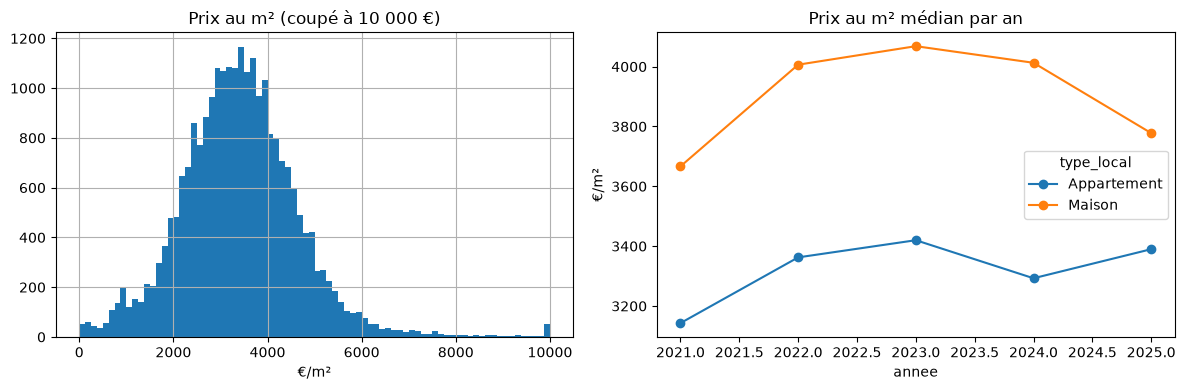

In [29]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

simples["prix_m2"].clip(upper=10_000).hist(bins=80, ax=axes[0])
axes[0].set_title("Prix au m² (coupé à 10 000 €)")
axes[0].set_xlabel("€/m²")

simples.groupby(["annee", "type_local"])["prix_m2"].median().unstack().plot(marker="o", ax=axes[1])
axes[1].set_title("Prix au m² médian par an")
axes[1].set_ylabel("€/m²")

plt.tight_layout()
plt.show()

In [30]:
import folium

data_carte = simples.dropna(subset=["latitude", "longitude"]).query("1000 < prix_m2 < 8000")
echantillon = data_carte.sample(min(2000, len(data_carte)), random_state=42)


def couleur(prix):
    if prix < 3000:
        return "#2b83ba"
    if prix < 4000:
        return "#abdda4"
    if prix < 5000:
        return "#fdae61"
    return "#d7191c"


carte = folium.Map(location=[43.6108, 3.8767], zoom_start=13, tiles="OpenStreetMap")
for _, r in echantillon.iterrows():
    folium.CircleMarker(
        [r.latitude, r.longitude],
        radius=3,
        color=couleur(r.prix_m2),
        fill=True,
        fill_opacity=0.7,
        popup=f"{r.type_local} · {r.surface_reelle_bati:.0f} m² · {r.prix_m2:,.0f} €/m²",
    ).add_to(carte)

carte.save("../carte_prix_m2.html")
carte

In [31]:
print("Lignes :", len(df))
print("Ventes uniques :", df["id_mutation"].nunique())
print("Années :", sorted(df["annee"].unique()))

print("\nPrix au m² médian :")
print(simples.groupby("type_local")["prix_m2"].median().round(0))

colonnes = ["id_mutation", "type_local", "valeur_fonciere", "surface_reelle_bati", "prix_m2"]
print("\nLes 3 prix au m² les plus bas :")
print(simples.sort_values("prix_m2")[colonnes].head(3))
print("\nLes 3 prix au m² les plus hauts :")
print(simples.sort_values("prix_m2")[colonnes].tail(3))

Lignes : 81361
Ventes uniques : 35963
Années : [np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]

Prix au m² médian :
type_local
Appartement    3319.0
Maison         3917.0
Name: prix_m2, dtype: float64

Les 3 prix au m² les plus bas :
       id_mutation   type_local  valeur_fonciere  surface_reelle_bati  \
59537  2024-400977       Maison              1.0                200.0   
71288  2025-423883  Appartement              1.0                125.0   
9613   2021-557206  Appartement              1.0                 85.0   

        prix_m2  
59537  0.005000  
71288  0.008000  
9613   0.011765  

Les 3 prix au m² les plus hauts :
       id_mutation   type_local  valeur_fonciere  surface_reelle_bati  prix_m2
64870  2024-408264  Appartement              NaN                 64.0      NaN
74285  2025-428330  Appartement              NaN                117.0      NaN
80452  2025-436914  Appartement              NaN                 38.0      NaN
